489 Case

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#statsmodels
import statsmodels.api as sm

#Scikit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split, cross_val_predict

#torch
import torch
import torch.nn as nn
import torch.utils.data as Data
from torch.autograd import Variable

#captum
from captum.attr import IntegratedGradients
from captum.attr import LayerConductance
from captum.attr import NeuronConductance

def func_turn_df_into_t_float(df_arg):
    t_ret = torch.from_numpy(np.array(df_arg))
    t_ret = t_ret.to(torch.float)
    return t_ret

def func_turn_df_into_t_long(df_arg):
    t_ret = torch.from_numpy(np.array(df_arg))
    t_ret = t_ret.to(torch.long)
    return t_ret

mySEED = 2023
myRANDOM_STATE = mySEED # for split train/eval
myTEST_PERCENTAGE = 0.1
torch.manual_seed(mySEED) #always first

targetDirectory = "C:\\CASES\\PYTPRA"
os.chdir(targetDirectory)#hier sucht Python nach csv Datei
data = pd.read_csv('CaseBGB489.csv', delimiter=';', decimal = ',') # STROKE
# Überprüfen auf redundante und/oder NaN Daten
if data.duplicated().sum() > 0:
    data = data.drop_duplicates()
    print('Redundante Daten wurden entfernt.')
    print('--------------------------')

if data.isna().any().sum() > 0:
    data = data.dropna()
    print('NaN-Daten wurden entfernt.')
    print('--------------------------')
print(data.shape)
print(data.head())
print("Working directory in use: ", os. getcwd())

Redundante Daten wurden entfernt.
--------------------------
(138, 9)
   AUSUEBUNG  SELBSTAENDIG  BERATUNGSOFFEN  ALTER  MONATSNETTO  NOMINALZINS  \
0        1.0           0.0             0.0   61.0          0.0         5.39   
1        0.0           0.0             1.0   46.0     150000.0         4.30   
2        0.0           0.0             1.0   54.0      10000.0         5.08   
3        0.0           0.0             0.0   62.0          0.0         5.00   
4        1.0           0.0             1.0   58.0      90000.0         4.95   

   GESAMTZUSAGE  URSPRUNGSLAUFZEIT  RECHTVERFUEGBARSEIT  
0       90000.0              180.0                 23.0  
1       70000.0              180.0                  1.0  
2      120000.0              181.0                 54.0  
3       70000.0              166.0                 29.0  
4      460000.0              179.0                 15.0  
Working directory in use:  C:\CASES\PYTPRA


In [2]:
X = data[['SELBSTAENDIG', 'BERATUNGSOFFEN', 'ALTER', 'MONATSNETTO', 'NOMINALZINS', 'GESAMTZUSAGE', 
          'URSPRUNGSLAUFZEIT', 'RECHTVERFUEGBARSEIT']]
y = data['AUSUEBUNG']


# Datensatz in Trainings- und Testdaten aufteilen

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=myTEST_PERCENTAGE, random_state=myRANDOM_STATE)

x_temp = sm.add_constant(X_train)
log_reg = sm.Logit(y_train, x_temp).fit()
print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.313769
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              AUSUEBUNG   No. Observations:                  124
Model:                          Logit   Df Residuals:                      115
Method:                           MLE   Df Model:                            8
Date:                Thu, 13 Feb 2025   Pseudo R-squ.:                  0.4012
Time:                        14:26:59   Log-Likelihood:                -38.907
converged:                       True   LL-Null:                       -64.980
Covariance Type:            nonrobust   LLR p-value:                 1.577e-08
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 -19.8710      5.519     -3.601      0.000     -30.687      -9.055
SE

In [3]:
# Standardisierung
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
#prep torch data
t_X_train = func_turn_df_into_t_float(X_train_scaled)
t_X_valid = func_turn_df_into_t_float(X_test_scaled)

t_y_train = func_turn_df_into_t_long(y_train)
t_y_valid = func_turn_df_into_t_long(y_test)

In [5]:
myHIDDENone = 6 #we have 8 dim input + 1 out = 9, two thirds = 6
myMAX_EPOCHS = 500 #500 #more than 2000 does not pay off, valid error does not change thereafter, 500 is ok
myLEARNING_RATE = 0.1
myBATCH_SIZE = 32 #32 is min

In [6]:
#PyTorch MLP

torch_dataset = Data.TensorDataset(t_X_train, t_y_train)
train_loader = Data.DataLoader(
    dataset=torch_dataset, 
    batch_size=myBATCH_SIZE, 
    shuffle=True, num_workers=0,)#use default

model_pt = nn.Sequential(nn.Linear(8, myHIDDENone),
                      nn.Sigmoid(),
                      nn.Linear(myHIDDENone, 2), nn.Softmax(dim=1))

In [7]:
loss_fn = nn.CrossEntropyLoss() #watch this!
optimizer =  torch.optim.Adam(model_pt.parameters(), lr=myLEARNING_RATE)
#torch.optim.SGD(model_pt.parameters(), lr=0.5) is worse
losses_train = []
losses_val = []

def generic_training_loop_extended(n_epochs, optimizer, model, loss_fn, train_t_u, val_t_u,train_t_c, val_t_c):
    for epoch in range(1, n_epochs + 1):
        loss_train_avg = []
        for step, (batch_x, batch_y) in enumerate(train_loader): 
            b_x = Variable(batch_x)
            b_y = Variable(batch_y)
            train_t_p = model(b_x) #all details are in model
            train_loss = loss_fn(train_t_p, b_y) #and the loss function
            loss_train_avg.append(train_loss.item()) 
            optimizer.zero_grad()
            train_loss.backward() 
            optimizer.step()
        with torch.no_grad(): 
            val_t_p = model(val_t_u)
            val_loss = loss_fn(val_t_p, val_t_c)
            losses_val.append(val_loss.item()) 
            assert val_loss.requires_grad == False 
        losses_train.append(train_loss.item()) 
        if epoch <= 100 or epoch % 50 == 0:
            print("Epoch", {epoch}, f"Avg. training loss over all batches: {np.average(loss_train_avg[0:step]):.4f}", 
                  f"Validation loss:  {val_loss.item():.4f}",
                  "\n \tLast batch out of", {step}, f"has training loss: {train_loss.item():.4f}")    
    
    return 

generic_training_loop_extended(n_epochs = myMAX_EPOCHS, optimizer = optimizer, model = model_pt,
                      loss_fn = loss_fn , train_t_u = t_X_train, val_t_u = t_X_valid, 
                      train_t_c = t_y_train, val_t_c = t_y_valid)

Epoch {1} Avg. training loss over all batches: 0.6161 Validation loss:  0.5975 
 	Last batch out of {3} has training loss: 0.5467
Epoch {2} Avg. training loss over all batches: 0.5222 Validation loss:  0.5956 
 	Last batch out of {3} has training loss: 0.5184
Epoch {3} Avg. training loss over all batches: 0.5462 Validation loss:  0.5941 
 	Last batch out of {3} has training loss: 0.4145
Epoch {4} Avg. training loss over all batches: 0.4910 Validation loss:  0.5893 
 	Last batch out of {3} has training loss: 0.5657
Epoch {5} Avg. training loss over all batches: 0.4775 Validation loss:  0.5771 
 	Last batch out of {3} has training loss: 0.5563
Epoch {6} Avg. training loss over all batches: 0.4816 Validation loss:  0.5597 
 	Last batch out of {3} has training loss: 0.4812
Epoch {7} Avg. training loss over all batches: 0.4502 Validation loss:  0.5408 
 	Last batch out of {3} has training loss: 0.5194
Epoch {8} Avg. training loss over all batches: 0.4700 Validation loss:  0.5285 
 	Last bat

Epoch {71} Avg. training loss over all batches: 0.3498 Validation loss:  0.4033 
 	Last batch out of {3} has training loss: 0.3800
Epoch {72} Avg. training loss over all batches: 0.3477 Validation loss:  0.4039 
 	Last batch out of {3} has training loss: 0.3857
Epoch {73} Avg. training loss over all batches: 0.3282 Validation loss:  0.4034 
 	Last batch out of {3} has training loss: 0.4528
Epoch {74} Avg. training loss over all batches: 0.3558 Validation loss:  0.4031 
 	Last batch out of {3} has training loss: 0.3582
Epoch {75} Avg. training loss over all batches: 0.3566 Validation loss:  0.4026 
 	Last batch out of {3} has training loss: 0.3540
Epoch {76} Avg. training loss over all batches: 0.3575 Validation loss:  0.4015 
 	Last batch out of {3} has training loss: 0.3507
Epoch {77} Avg. training loss over all batches: 0.3479 Validation loss:  0.4014 
 	Last batch out of {3} has training loss: 0.3824
Epoch {78} Avg. training loss over all batches: 0.3572 Validation loss:  0.4015 
 	

In [8]:
#inspect model
ig = IntegratedGradients(model_pt)#Specifically, integrated gradients
#are defined as the path intergral of the gradients along the straightline path
#see https://arxiv.org/pdf/1703.01365.pdf
ig_input_tensor = t_X_train
ig_input_tensor.requires_grad_()
attr, delta = ig.attribute(ig_input_tensor,target=0, return_convergence_delta=True)
#target class No 0 because we only have one output dimension
attr = attr.detach().numpy()
np.round(attr,2)
importances = np.mean(attr, axis=0)
feature_names = list(X_train.columns)
for i in range(len(feature_names)):
        print(feature_names[i], ": ", '%.3f'%(importances[i]))

SELBSTAENDIG :  -0.042
BERATUNGSOFFEN :  0.018
ALTER :  -0.011
MONATSNETTO :  -0.025
NOMINALZINS :  -0.083
GESAMTZUSAGE :  0.029
URSPRUNGSLAUFZEIT :  -0.041
RECHTVERFUEGBARSEIT :  -0.047


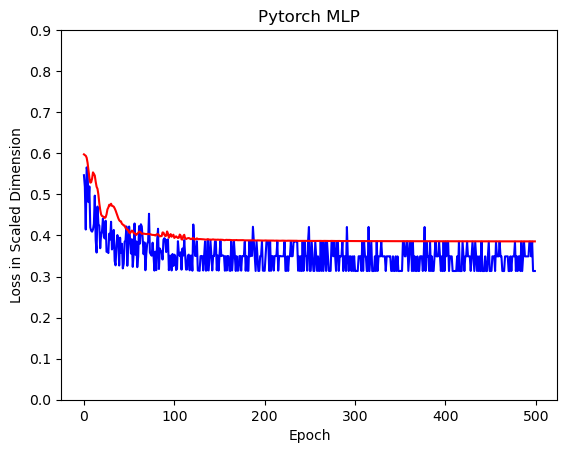

In [9]:
t_ctr = torch.arange(0, myMAX_EPOCHS, step = 1)
#t_ctr = t_ctr.clone().detach().unsqueeze(1)
plt.plot(t_ctr, losses_train, 'b') # plotting separately 
plt.plot(t_ctr, losses_val, 'r') 
plt.ylabel('Loss in Scaled Dimension')
plt.xlabel('Epoch')
plt.title('Pytorch MLP')
plt.ylim(top = 0.9)
plt.ylim(bottom = 0)
plt.show()

In [10]:
#forecast Logit
x_temp = sm.add_constant(X_train)
yhat_train = log_reg.predict(x_temp)
prediction_train = list(map(round, yhat_train))
x_temp = sm.add_constant(X_test)
yhat_test = log_reg.predict(x_temp)
prediction_test = list(map(round, yhat_test))

In [11]:
#forecasts MLP
out_probs_val = model_pt(t_X_valid).detach().numpy()
print(out_probs_val)
out_classes_val = np.argmax(out_probs_val, axis=1)
print(out_classes_val)

out_probs_train = model_pt(t_X_train).detach().numpy()
out_classes_train = np.argmax(out_probs_train, axis=1)

out_probs_test = model_pt(t_X_valid).detach().numpy()
out_classes_test = np.argmax(out_probs_test, axis=1)

[[2.3292138e-03 9.9767083e-01]
 [8.5959648e-04 9.9914038e-01]
 [1.0000000e+00 1.6446583e-21]
 [9.9999177e-01 8.2145398e-06]
 [9.9795222e-01 2.0477595e-03]
 [1.0000000e+00 2.9423741e-21]
 [1.7674839e-02 9.8232520e-01]
 [7.2046831e-05 9.9992800e-01]
 [9.9716043e-01 2.8395932e-03]
 [1.0000000e+00 3.4280630e-21]
 [1.0000000e+00 8.6655833e-22]
 [8.7544129e-07 9.9999917e-01]
 [9.9984765e-01 1.5238411e-04]
 [1.0000000e+00 2.2555141e-14]]
[1 1 0 0 0 0 1 1 0 0 0 1 0 0]


In [12]:
print("\nCOMPARISON ON TEST SET=================")
print('Number of exercises in test data', sum(y_test))
print('As percentage %.3f ' %  (sum(y_test)/len(y_test)))
print('Benchmark Accuracy on train data %.3f '%  (1-sum(y_train)/len(y_train)))
print('Benchmark Accuracy on test data %.3f \n' %  (1-sum(y_test)/len(y_test)))

print('Accuracy  Logit on train data: %.3f ' % accuracy_score(y_train, prediction_train))
print('Confusion Matrix Logit on train data: \n', confusion_matrix(y_train, prediction_train))
print('Accuracy  Logit on test data: %.3f ' % accuracy_score(y_test, prediction_test))
#print('Precision Logit on test data: %.3f ' %  precision_score(y_test, prediction))
print('Confusion Matrix Logit on test data: \n', confusion_matrix(y_test, prediction_test))

#The precision is the ratio tp / (tp + fp) where tp is the number of true positives 
#and fp the number of false positives. The precision is intuitively 
#the ability of the classifier not to label as positive a sample that is negative.
#the best value is 1 and the worst value is 0.
#print('Benchmark Accuracy on test data %.3f \n' %  (1-sum(y_test)/len(y_test)))
print('Accuracy  MLP on train data: %.3f ' % (sum(out_classes_train == y_train) / len(y_train)))
print('Confusion Matrix MLP on train data:\n', confusion_matrix(y_train, out_classes_train))
print('Accuracy  MLP on test data: %.3f ' % (sum(out_classes_val == y_test) / len(y_test)))
print('Confusion Matrix MLP on test data:\n', confusion_matrix(y_test, out_classes_test))
print("\nXXX DONE XXX")


COMPARISON ON TEST SET=================
Number of exercises in test data 4.0
As percentage 0.286 
Benchmark Accuracy on train data 0.782 
Benchmark Accuracy on test data 0.714 

Accuracy  Logit on train data: 0.847 
Confusion Matrix Logit on train data: 
 [[90  7]
 [12 15]]
Accuracy  Logit on test data: 0.643 
Confusion Matrix Logit on test data: 
 [[9 1]
 [4 0]]
Accuracy  MLP on train data: 0.968 
Confusion Matrix MLP on train data:
 [[96  1]
 [ 3 24]]
Accuracy  MLP on test data: 0.929 
Confusion Matrix MLP on test data:
 [[9 1]
 [0 4]]

XXX DONE XXX
